# Parte 2
#### Miguel Pereira - Alejandro Gaona

In [1]:
#Si ocurre algún error de dependencias (ya que yo trabajé utilizando un ambiente virtual de Python), descomentar la siguiente línea y correr el notebook
#!pip install -r requirements.txt

En esta celda, importamos las librerías que se utilizarán para procesar el dataset de UCI "Human Activity Recognition Using Smartphones" (llamado *UCI HAR* de ahora en adelante).
Utilizaremos:
* Pandas: Procesamiento base del dataset.
* Matplotlib: Graficar distribución de los datos.
* Numpy: Procesamiento matemático.
* Scikit-Learn (*sklearn*): Agrupación en K-medias.
* HMMLearn: Implementación de modelo oculto de Markov (*HMM*).

In [2]:
#import block
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from hmmlearn import hmm

Cargamos los datos del dataset en formato de listas.

In [3]:
#data load block

features_df = pd.read_csv('UCI HAR Dataset/features.txt', sep='\\s+', header=None, names=['column_index', 'feature_name'])
column_names = features_df['feature_name'].tolist()
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\\s+', header=None)
X_train.columns = column_names
y_train_raw = pd.read_csv('UCI HAR Dataset/train/y_train.txt', header=None, names=['activity_label'])
y_train = y_train_raw['activity_label'] - 1
subjects = pd.read_csv('UCI HAR Dataset/train/subject_train.txt', header=None, names=['subject'])


Definimos las observaciones con los índices:

$$I_{acc} = \frac{tBodyAccMag\text{-}mean() + tBodyAccMag\text{-}std()}{2}$$
$$I_{gyro} = \frac{tBodyGyroMag\text{-}mean() + tBodyGyroMag\text{-}std()}{2}$$

In [4]:
I_acc = (X_train['tBodyAccMag-mean()'] + X_train['tBodyAccMag-std()']) / 2
I_gyro = (X_train['tBodyGyroMag-mean()'] + X_train['tBodyGyroMag-std()']) / 2

Y para determinar qué tipo de discretización usar, realizamos un histograma para observar la distribución de los datos:

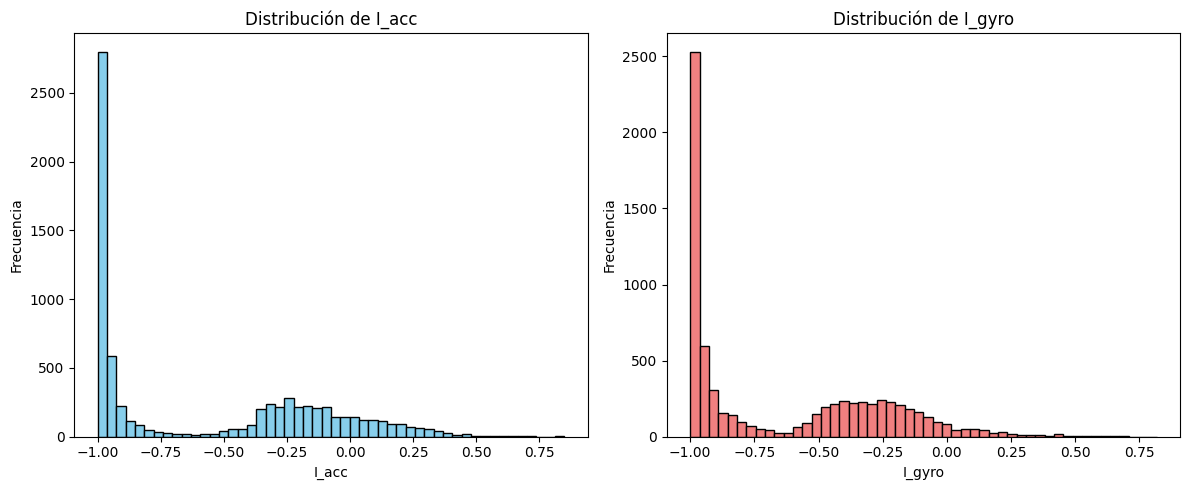

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(I_acc, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de I_acc')
plt.xlabel('I_acc')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(I_gyro, bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribución de I_gyro')
plt.xlabel('I_gyro')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se puede observar en ambos dos áreas principales: una frecuencia muy alta al inicio, seguido de una drástica baja, y una agrupación de frecuencias entre -0.5 y 0.25. Esto representa una **distribución multimodal**, por lo que una buena forma de discretizar es utilizando agrupación *K-medias/K-means*. Para esto utilizamos la librería *sklearn*.

In [6]:
#se debe transformar de lista a matriz para utilizar sklearn
acc_data = I_acc.values.reshape(-1, 1)
gyro_data = I_gyro.values.reshape(-1, 1)

kmeans_acc = KMeans(n_clusters=3, random_state=0, n_init='auto')
labels_acc = kmeans_acc.fit_predict(acc_data)
kmeans_gyro = KMeans(n_clusters=3, random_state=0, n_init='auto')
labels_gyro = kmeans_gyro.fit_predict(gyro_data)

#como kmeans tiene un ordenamiento aleatorio para las labels, se crea una función para ordenarlos en low, mid y high

def order_kmean_labels(kmeans_model, labels):
    centers = kmeans_model.cluster_centers_.flatten()
    ordered_index = np.argsort(centers)
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(ordered_index)}
    ordered_labels = np.vectorize(label_mapping.get)(labels)
    return ordered_labels

acc_states = order_kmean_labels(kmeans_acc, labels_acc)
gyro_states = order_kmean_labels(kmeans_gyro, labels_gyro)

Con esto, definimos el HMM de la siguiente forma:

**Observaciones:**
* 0: Acc-Low/Gyro-Low
* 1: Acc-Low/Gyro-Mid
* 2: Acc-Low/Gyro-High
* 3: Acc-Mid/Gyro-Low
* 4: Acc-Mid/Gyro-Mid
* 5: Acc-Mid/Gyro-High
* 6: Acc-High/Gyro-Low
* 7: Acc-High/Gyro-Mid
* 8: Acc-High/Gyro-High

*Nota: Low, Mid y High corresponden a Bajo, Medio y Alto, respectivamente.*

**Estados:**
* 0: Walking (Caminando)
* 1: Walking Upstairs (Caminando hacia arriba)
* 2: Walking Downstairs (Caminando hacia abajo)
* 3: Sitting (Sentado)
* 4: Standing (De pie)
* 5: Laying (Recostado)

Se calculan el vector inicial, la matriz de transición y la matriz de emisión de forma manual (sin hmmlearn).

In [7]:
n_states = 6
n_obs = 9
observations = (acc_states * 3) + gyro_states

df = pd.DataFrame({
    'subject': subjects['subject'],
    'state': y_train, #0 = walking, 1 = walking_downstairs, ..., 5 = laying
    'observation': observations #0 = low, 1 = mid, 2 = high
})

initial_states = df.groupby('subject')['state'].first()
initial_counts = initial_states.value_counts().reindex(range(n_states), fill_value=0)
initial_vector = initial_counts.values / initial_counts.sum()

transition_matrix = np.zeros((n_states, n_states))
for subject, group in df.groupby('subject'):
    states = group['state'].values
    for i in range(len(states) - 1):
        curr_state = states[i]
        next_state = states[i + 1]
        transition_matrix[curr_state, next_state] += 1

trans_row_sums = transition_matrix.sum(axis=1, keepdims=True)
transition_matrix = transition_matrix / trans_row_sums #para evitar división por 0

emission_matrix = np.zeros((n_states, n_obs))
for state in range(n_states):
    obs_in_state = df[df['state'] == state]['observation']
    obs_counts = obs_in_state.value_counts().reindex(range(n_obs), fill_value=0)
    emission_matrix[state, :] = obs_counts.values

ems_row_sums = emission_matrix.sum(axis=1, keepdims=True)
emission_matrix = emission_matrix / ems_row_sums
print(f"Vector inicial: {initial_vector}")

#display de las matrices
state_labels = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']
obs_labels = [f'Obs {i}' for i in range(9)]

print("Matriz de transición")
trans_df = pd.DataFrame(transition_matrix, index=state_labels, columns=state_labels)
display(trans_df)

print("\nMatriz de emisión")
ems_df = pd.DataFrame(emission_matrix, index=state_labels, columns=obs_labels)
display(ems_df)

Vector inicial: [0. 0. 0. 0. 1. 0.]
Matriz de transición


,Walking,Walking Upstairs,Walking Downstairs,Sitting,Standing,Laying
Walking,0.965742,0.000000,0.034258,0.000000,0.000000,0.000000
Walking Upstairs,0.000000,0.966793,0.013283,0.000000,0.019924,0.000000
Walking Downstairs,0.000000,0.054878,0.945122,0.000000,0.000000,0.000000
Sitting,0.000000,0.000000,0.000000,0.966563,0.000000,0.033437
Standing,0.000000,0.000000,0.000000,0.030568,0.969432,0.000000
Laying,0.029851,0.000000,0.000000,0.000711,0.000000,0.969439



Matriz de emisión


,Obs 0,Obs 1,Obs 2,Obs 3,Obs 4,Obs 5,Obs 6,Obs 7,Obs 8
Walking,0.000000,0.000000,0.0,0.000000,0.702284,0.221044,0.000000,0.025285,0.051387
Walking Upstairs,0.000000,0.000000,0.0,0.000932,0.555452,0.205033,0.000000,0.077353,0.161230
Walking Downstairs,0.000000,0.000000,0.0,0.000000,0.105477,0.045639,0.000000,0.393509,0.455375
Sitting,0.965008,0.006998,0.0,0.021773,0.005443,0.000778,0.000000,0.000000,0.000000
Standing,0.984716,0.009461,0.0,0.004367,0.001456,0.000000,0.000000,0.000000,0.000000
Laying,0.952381,0.007818,0.0,0.021322,0.008529,0.000711,0.002843,0.004975,0.001421


Ahora, con los parametros calculados, construímos el HMM utilizando *hmmlearn*.

In [8]:
har_model = hmm.CategoricalHMM(n_components=n_states, init_params="")
har_model.startprob_ = initial_vector
har_model.transmat_ = transition_matrix
har_model.emissionprob_ = emission_matrix

Se selecciona una subsecuencia de 100 observaciones, vista a continuación.

In [9]:
data_sub_one = df[df['subject'] == 1]
subseq = data_sub_one['observation'].values[:100].reshape(-1, 1)
#por si acaso, igual tomamos los estados reales
subseq_real_states = data_sub_one['state'].values[:100]

flat_subseq = subseq.flatten()
line_len = 20
print("Subsecuencia de observaciones:")
print("------------------------------")
for i in range(0, len(flat_subseq), line_len):
    line = flat_subseq[i : i + line_len]
    path_string = " -> ".join(map(str, line))
    print(f"t={i:02d} a t={i+len(line)-1:02d} |  {path_string}")

Subsecuencia de observaciones:
------------------------------
t=00 a t=19 |  0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0
t=20 a t=39 |  0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 3 -> 0 -> 0 -> 1 -> 4 -> 3 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0
t=40 a t=59 |  0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0
t=60 a t=79 |  0 -> 0 -> 0 -> 0 -> 3 -> 0 -> 4 -> 4 -> 0 -> 1 -> 8 -> 8 -> 3 -> 0 -> 0 -> 0 -> 0 -> 0 -> 5 -> 5
t=80 a t=99 |  5 -> 5 -> 5 -> 5 -> 4 -> 5 -> 4 -> 4 -> 4 -> 4 -> 5 -> 5 -> 4 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5


Ahora aplicamos Forward-Backward. En *hmmlearn*, no existe directamente una función con este nombre, pero la función "predict_proba()" aplica este algoritmo.

In [10]:
probs_fb = har_model.predict_proba(subseq)

Esto resulta en una matriz de $100 \times 6$, con componentes $a_{ts}$, con $t$ correspondiendo al instante (entre 0 y 99), y $s$ correspondiendo al estado (entre 0 y 5, definidos anteriormente). Sobre esta, podemos realizar consultas sobre probabilidades de estados.

In [11]:
#estado más probable en t = 4
t4_probs = probs_fb[4]
likely_state_t4 = np.argmax(t4_probs)
prob_likely_state_t4 = t4_probs[likely_state_t4]
print(f"El estado más probable en t = 4 es {likely_state_t4}, con una probabilidad de {prob_likely_state_t4}")

#probabilidad de estado 5 en t = 19
prob_laying_t19 = probs_fb[19, 5]
print(f"La probabilidad del estado 5 en t = 19 es de {prob_laying_t19}")

#estado menos probable en t = 36
t36_probs = probs_fb[36]
least_likely_state_t36 = np.argmin(t36_probs)
prob_least_likely_state_t36 = t36_probs[least_likely_state_t36]
print(f"El estado menos probable en t = 36 es {least_likely_state_t36}, con una probabilidad de {prob_least_likely_state_t36}")

#momento más probable para estado 0
probs_walking = probs_fb[:, 0]
likely_time_walking = np.argmax(probs_walking)
prob_likely_walking_time = probs_walking[likely_time_walking]
print(f"El momento más probable para el estado 0 es t = {likely_time_walking}, con una probabilidad de {prob_likely_walking_time}")

El estado más probable en t = 4 es 4, con una probabilidad de 0.8636003290443707
La probabilidad del estado 5 en t = 19 es de 0.10908298081431396
El estado menos probable en t = 36 es 0, con una probabilidad de 0.0
El momento más probable para el estado 0 es t = 79, con una probabilidad de 0.9999435918718768


Ahora, utilizando la misma subsecuencia, aplicamos el algoritmo Viterbi para obtener la secuencia de estados más probable, y la probabilidad asociada a este camino. Al igual que con el Forward-Backward, no existe una función directamente llamada "viterbi()", pero la función "decode()" aplica Viterbi y retorna ambos parametros. Ya que la probabilidad es entregada en forma logarítmica, también la transformamos a un formato familiar.

In [12]:
#en hmmlearn, decode() aplica viterbi y retora probabilidad (logaritmica) y la secuencia en un array
subseq_prob_raw, subseq_viterbi_states = har_model.decode(subseq)
subseq_prob = np.exp(subseq_prob_raw)

flat_state_subseq = subseq_viterbi_states.flatten()
print("Subsecuencia de estados más probable:")
print("------------------------------")
for i in range(0, len(flat_state_subseq), line_len):
    line = flat_state_subseq[i : i + line_len]
    path_string = " -> ".join(map(str, line))
    print(f"t={i:02d} a t={i+len(line)-1:02d} |  {path_string}")

print(f"La probabilidad de la subsecuencia de estados sería de: {subseq_prob}")

#probabilidad de la secuencia observada
sec_prob_raw = har_model.score(subseq)
sec_prob = np.exp(sec_prob_raw)
print(f"La probabilidad de la secuencia de estados observados sería de: {sec_prob}")

Subsecuencia de estados más probable:
------------------------------
t=00 a t=19 |  4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4
t=20 a t=39 |  4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 4 -> 3 -> 3 -> 3 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5
t=40 a t=59 |  5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5
t=60 a t=79 |  5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 5 -> 0 -> 0
t=80 a t=99 |  0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0 -> 0
La probabilidad de la subsecuencia de estados sería de: 8.622480311075958e-42
La probabilidad de la secuencia de estados observados sería de: 7.457748479142804e-39


## Análisis

El dataset procesado corresponde a los movimientos de acelerómetro y giroscopio de un smartphone en la cintura de sujetos. Se puede observar que un movimiento "bajo" de los sensores más probablemente corresponde al estado 4 (De pie/*Standing*), y que generalmente, los estados más probables tienden a ser el 4 y 5 (De pie/*Standing* y Sentado/*Sitting*). Esto da a entender que los sujetos, y extrapolando a la población general, pasa buena parte del día de pie quietos, o sentados.